In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Advertising.csv", index_col= 0)
print("set up complete")

set up complete


In [2]:
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
X = df.drop(
    "sales",
    axis= 1
).to_numpy()

y = df[['sales']].to_numpy()

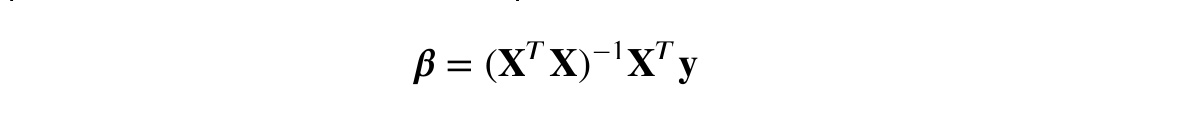

In [4]:
X = np.concat(
    (np.ones(
        (X.shape[0],
         1
        )
    ),X),
    axis= 1
)

In [5]:
X.shape

(200, 4)

In [6]:
betas = np.linalg.inv(
    np.dot(
        X.T,
        X
    )).dot(X.T).dot(y)

betas

array([[ 2.93888937e+00],
       [ 4.57646455e-02],
       [ 1.88530017e-01],
       [-1.03749304e-03]])

In [7]:
betas = betas.flatten()
betas

array([ 2.93888937e+00,  4.57646455e-02,  1.88530017e-01, -1.03749304e-03])

In [8]:
print(f"y = {betas[0]:.3f} + {betas[1]:.3f} x1 + {betas[2]:.3f} x2 + ({betas[3]:.3f}) x3")

y = 2.939 + 0.046 x1 + 0.189 x2 + (-0.001) x3


# SKlearn Implementation

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import max_error, mean_absolute_error, mean_squared_error, r2_score

In [10]:
X = df.drop(
    'sales',
    axis= 1
    ).to_numpy()

y = df[['sales']].to_numpy()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.2,
    random_state= 987
)

In [12]:
linear_regression = LinearRegression()
linear_regression.fit(
    X_train, 
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 3)","[[ 0.05, 0.19,-0. ]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2.87]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[1079.57, 277.13, 170.48]"


In [13]:
# Beta_0
linear_regression.intercept_

array([2.8746144])

In [14]:
# Beta_1
linear_regression.coef_

array([[ 0.04606898,  0.18712568, -0.00054721]])

In [15]:
SSE = np.sum(
    np.power(
        y_train - linear_regression.predict(X_train),
        2
    )
)

SSE

np.float64(450.8625569779802)

In [16]:
y_pred = linear_regression.predict(X_test)

In [17]:
# max_error
max_error(
    y_test,
    y_pred
)

4.23932051851552

In [18]:
# mean_absolute_error
mean_absolute_error(
    y_test,
    y_pred
)

1.3345278468817423

In [19]:
# mean_squared_error
mean_squared_error(
    y_test,
    y_pred
)

2.661194761189463

In [20]:
# r2_score
r2_score(
    y_test,
    y_pred
)

0.9018693692889659

# Visualization

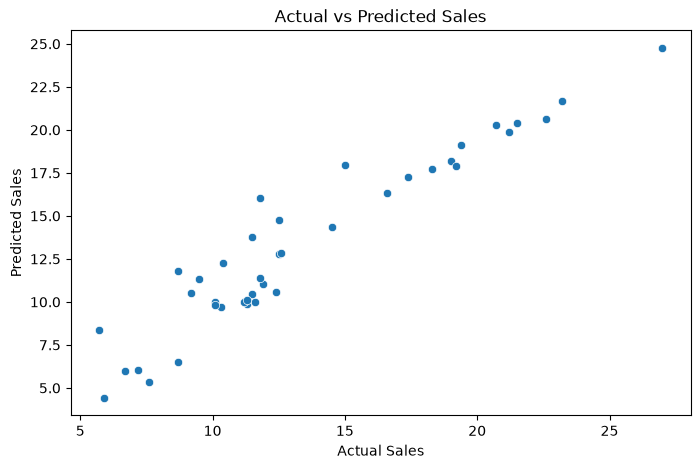

In [ ]:
# Actual vs Predicted
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test.flatten(),
    y=y_pred.flatten()
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


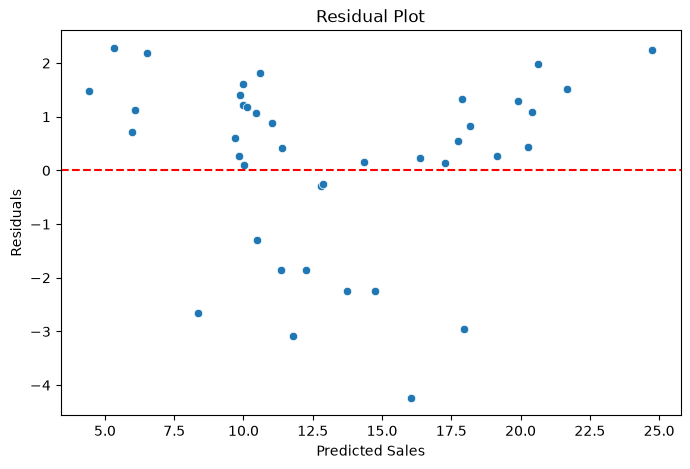

In [ ]:
# Residual Plot
residuals = y_test.flatten() - y_pred.flatten()

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred.flatten(),
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

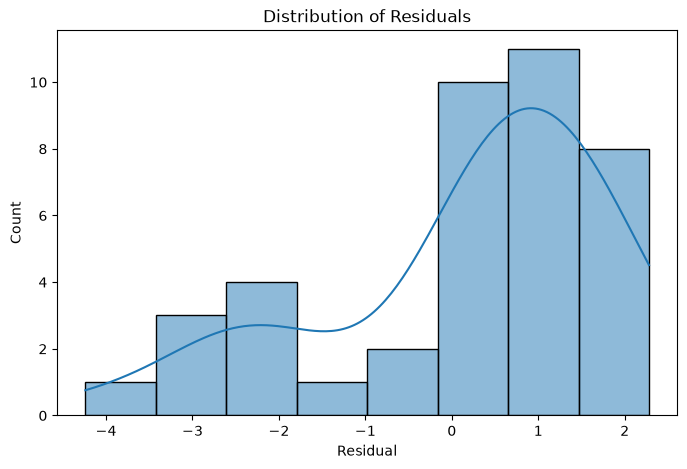

In [23]:
# Residual Distribution
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()